<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/20_polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import  Pipeline

import plotly.express as px
import plotly.graph_objects as go

In [2]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

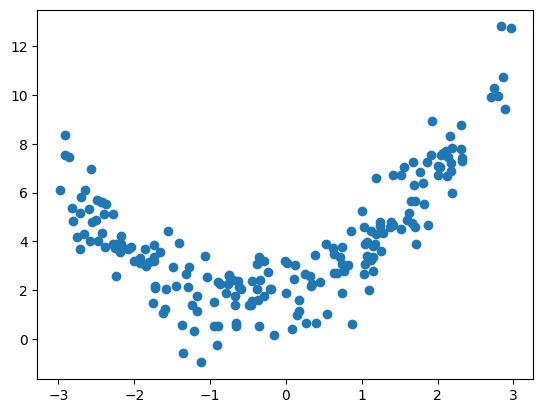

In [3]:
plt.scatter(X,y)

<Axes: ylabel='Density'>

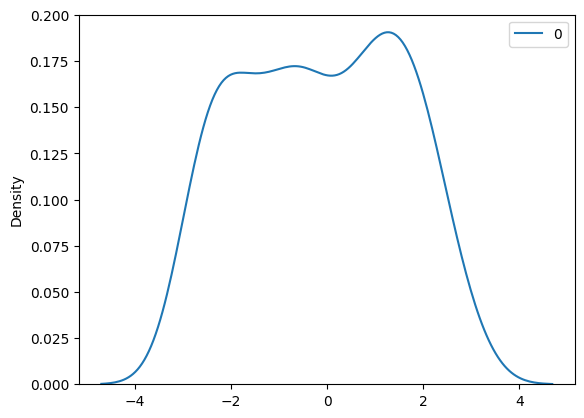

In [4]:
sns.kdeplot(X)

In [5]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=2)

In [6]:
lr=LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [7]:
y_pred=lr.predict(X_test)

In [8]:
r2_score(y_test, y_pred)

-0.04483788133611033

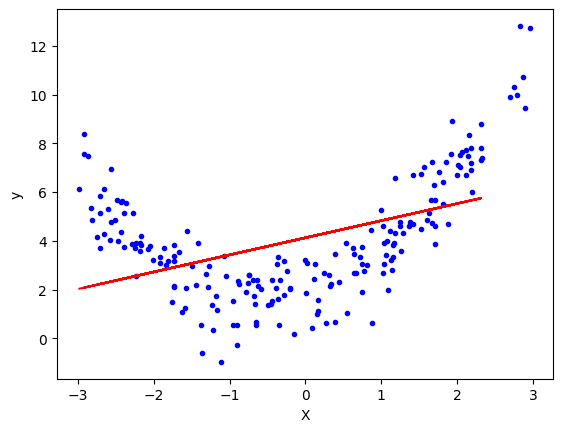

In [9]:
plt.plot(X, y,'b.')
plt.plot(X_test,y_pred,color="red")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [10]:
poly=PolynomialFeatures(degree=2)

In [11]:
X_train_trns=poly.fit_transform(X_train)


In [12]:
X_test_tns=poly.transform(X_test)

In [13]:
lr1=LinearRegression()
lr1.fit(X_train_trns, y_train)

LinearRegression()

In [14]:
poly.powers_

array([[0],
       [1],
       [2]])

In [15]:
y_pred=lr1.predict(X_test_tns)

In [16]:
r2_score(y_test,y_pred)

0.7970179708393118

In [17]:
lr1.coef_

array([[0.        , 0.87359288, 0.80195221]])

In [18]:
lr1.intercept_

array([1.91379316])

In [19]:
X_new= np.linspace(-3,3,100).reshape(100,1)
X_new_poly = poly.transform(X_new)

In [20]:
y_new=lr1.predict(X_new_poly)

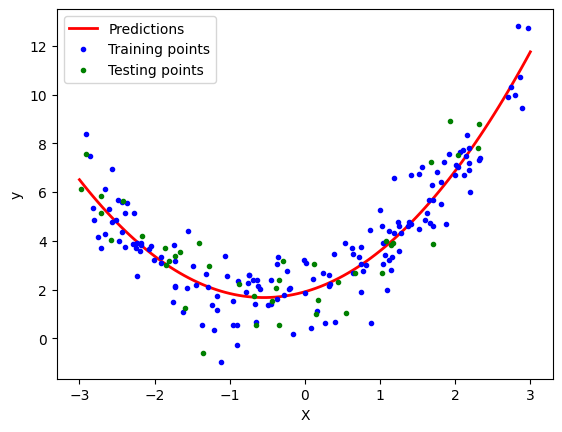

In [21]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

**Geberic Code**

In [22]:
def polyRegression(degree):

  poly_reg=PolynomialFeatures(degree=degree)
  X_train_trns=poly_reg.fit_transform(X)

  lr2=LinearRegression()
  lr2.fit(X_train_trns,y)

  X_new=np.linspace(-3,3,100).reshape(100,1)
  X_new_poly=poly_reg.transform(X_new)

  y_pred=lr2.predict(X_new_poly)

  plt.scatter(X,y)
  plt.plot(X_new,y_pred,color="red",label="Degree"+str(degree), linewidth=2)

  plt.legend(loc="upper left")
  plt.xlabel("X")
  plt.ylabel("y")
  plt.axis([-3, 3, 0, 10])
  plt.show()




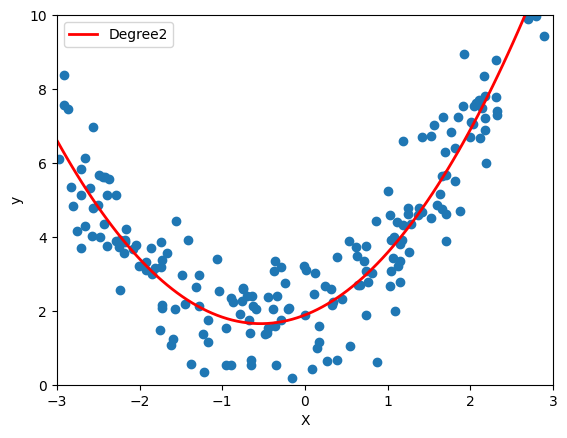

In [23]:
polyRegression(2)

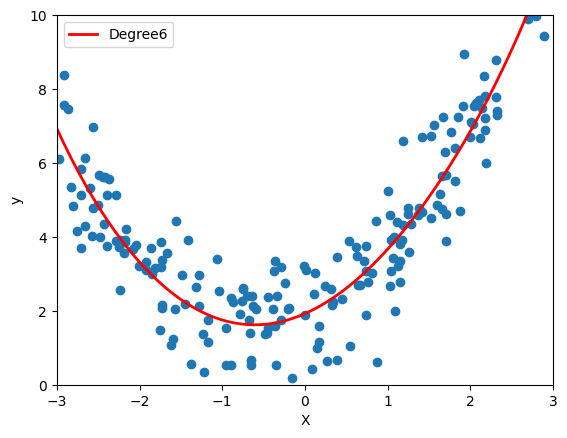

In [24]:
polyRegression(6)

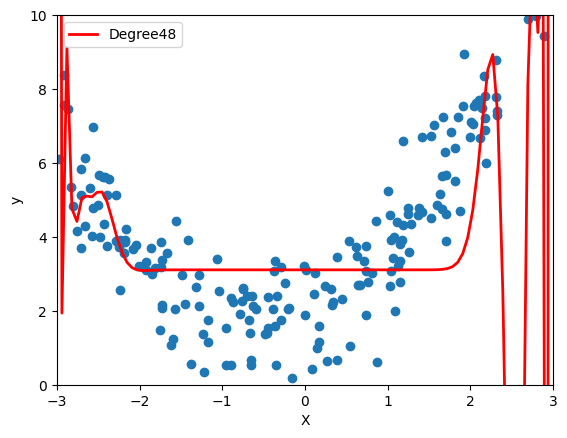

In [25]:
polyRegression(48)

In [26]:
def polyRegression_pipe(degree):

  X_new=np.linspace(-3,3,100).reshape(100,1)

  poly_reg=PolynomialFeatures(degree=degree)
  lr2=LinearRegression()
  x_std=StandardScaler()

  pipe=Pipeline([
      ("poly_reg",poly_reg),
      ("x_std",x_std),
      ("lr2",lr2)
  ])

  pipe.fit(X,y)
  y_pred=pipe.predict(X_new)

  plt.plot(X_new,y_pred,color="red",label="Degree"+str(degree), linewidth=2)
  plt.plot(X_train, y_train, "b.", linewidth=3)
  plt.plot(X_test, y_test, "g.", linewidth=3)
  plt.legend(loc="upper left")
  plt.xlabel("X")
  plt.ylabel("y")
  plt.axis([-3, 3, 0, 10])
  plt.show()




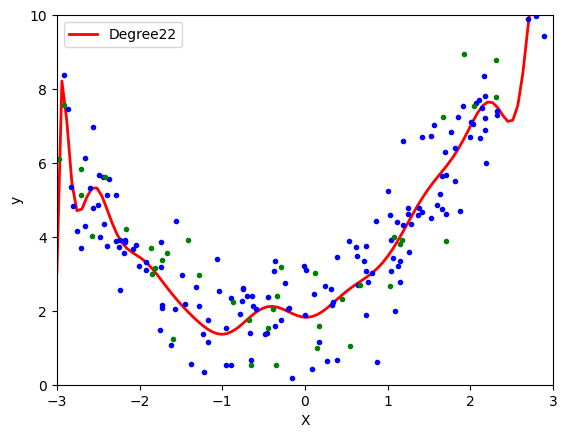

In [27]:
polyRegression_pipe(22)

In [28]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [29]:
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [30]:
X1=np.array([x,y]).reshape(100,2)


In [31]:
lr3=LinearRegression()
lr3.fit(X1,z)

LinearRegression()

In [32]:
x_input=np.linspace(x.min(), x.max(),10)
y_input=np.linspace(y.min(), y.max(),10)

In [33]:
xGrid, yGrid = np.meshgrid(x_input, y_input)

In [34]:
# Flatten both grids into 1D arrays
x_flat = xGrid.ravel().reshape(1,100)
y_flat = yGrid.ravel().reshape(1,100)

# Merge into a single 2D array of coordinate pairs
final = np.vstack([x_flat, y_flat]).T

In [35]:
z_final=lr3.predict(final).reshape(10,10)

In [36]:
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_final))
fig.show()

**PolyNomial Regression**

In [37]:
X1=np.array([x,y]).reshape(100,2)


In [38]:
poly_3d=PolynomialFeatures(degree=3)

In [49]:
X_trans=poly_3d.fit_transform(X1)
X_trans.shape

(100, 10)

In [40]:
print(poly_3d.n_features_in_)
print(poly_3d.n_output_features_)
print(poly_3d.powers_)

2
10
[[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]
 [3 0]
 [2 1]
 [1 2]
 [0 3]]


In [42]:
lr4=LinearRegression()
lr4.fit(X_trans,z)

LinearRegression()

In [45]:
X_test_multi = poly_3d.transform(final)

In [53]:
z_final = lr4.predict(X_test_multi).reshape(10,10)

In [54]:
X_test_multi.shape

(100, 10)

In [55]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()